# SRA Regulatory Risk Intelligence
## 03 — Prototype Regulatory Risk Model

This notebook develops a **transparent analytical prototype** that converts historical SRA decision data into a simple regulatory-risk indicator.

The purpose is not to predict misconduct or replace legal judgment. Instead, the model demonstrates how legal/regulatory outcomes can be translated into a structured scoring framework that is explainable, reproducible, auditable, and easy to challenge or modify.

> **Important:** The scores in this notebook are **not official SRA ratings** and should not be used to make legal, disciplinary, employment, or reputational decisions about any person or firm.


## 1. Import libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


## 2. Load the cleaned dataset

In [2]:
DATA_PATH = Path("../data/processed/sra_decisions_clean.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print(f"Rows: {len(df):,}")
print(f"Unique names: {df['Name'].nunique():,}")
print(f"Decision categories: {df['Decision'].nunique()}")
df.head()


Rows: 126
Unique names: 107
Decision categories: 11


,Name,SRA_ID,Decision,Date,Profile_URL,Snapshot_Appearances
0,Akbar Ifzal Ali,571258.0,Decisions to refer to SDT,2026-08-27,https://www.sra.org.uk/consumers/solicitor-check/571258/,2
1,Emma Rowe,279936.0,Decisions to refer to SDT,2026-08-27,https://www.sra.org.uk/consumers/solicitor-check/279936/,2
2,Heather Joan Roberts,393573.0,Condition,2026-08-26,https://www.sra.org.uk/consumers/solicitor-check/393573/,2
3,Azair Mahmood Alam,334162.0,Intervention,2026-08-25,https://www.sra.org.uk/consumers/solicitor-check/334162/,2
4,Lewis Duncan - 3,782329.0,Control of non-qualified staff (section 43/99 order),2026-08-25,https://www.sra.org.uk/consumers/solicitor-check/7823293/,2


## 3. Define the prototype severity framework

The model assigns a **severity weight from 1 to 5** to each decision category.

- **1 — Administrative / low analytical severity**
- **2 — Moderate**
- **3 — Elevated**
- **4 — High**
- **5 — Very high**

These are modelling choices for this portfolio project, not legal conclusions or official SRA classifications.


In [3]:
severity_map = {'Approval': 1, 'Condition': 2, 'Rebuke': 3, 'Regulatory settlement agreement': 4, 'Fine': 4, 'Intervention': 5, 'Referral to Solicitors Disciplinary Tribunal': 5, 'Solicitors Disciplinary Tribunal order': 5, 'SDT Order': 5, 'Approval of employment (section 41)': 3, 'Approval of employment (section 43)': 3, 'Control of non-qualified staff (section 43/99 order)': 3, 'Decisions to refer to SDT': 3, 'Termination of suspension of PC/registration': 3}

severity_table = pd.DataFrame(
    sorted(severity_map.items(), key=lambda x: (x[1], x[0])),
    columns=["Decision", "Severity_Score"]
)

severity_table


,Decision,Severity_Score
0,Approval,1
1,Condition,2
2,Approval of employment (section 41),3
3,Approval of employment (section 43),3
4,Control of non-qualified staff (section 43/99 order),3
5,Decisions to refer to SDT,3
6,Rebuke,3
7,Termination of suspension of PC/registration,3
8,Fine,4
9,Regulatory settlement agreement,4


## 4. Apply severity scores

In [4]:
df["Severity_Score"] = df["Decision"].map(severity_map).fillna(3).astype(int)
df[["Name", "Decision", "Date", "Severity_Score"]].head(10)


,Name,Decision,Date,Severity_Score
0,Akbar Ifzal Ali,Decisions to refer to SDT,2026-08-27,3
1,Emma Rowe,Decisions to refer to SDT,2026-08-27,3
2,Heather Joan Roberts,Condition,2026-08-26,2
3,Azair Mahmood Alam,Intervention,2026-08-25,5
4,Lewis Duncan - 3,Control of non-qualified staff (section 43/99 order),2026-08-25,3
5,Roundhay Solicitors,Intervention,2026-08-25,5
6,Siobhan Hall (Cook) - 3,Control of non-qualified staff (section 43/99 order),2026-08-24,3
7,Jeremy Brooke,Decisions to refer to SDT,2026-08-20,3
8,Michael G Wooldridge,Intervention,2026-08-19,5
9,Michael George Wooldridge,Intervention,2026-08-19,5


## 5. Build entity-level historical indicators

The prototype combines:
1. maximum severity;
2. average severity;
3. number of unique decisions; and
4. a simple recency proxy.

These are descriptive features, not proof of current risk.


In [5]:
latest_date = df["Date"].max()

entity = (
    df.groupby("Name", dropna=False)
    .agg(
        Decision_Count=("Decision", "count"),
        Max_Severity=("Severity_Score", "max"),
        Avg_Severity=("Severity_Score", "mean"),
        Latest_Decision_Date=("Date", "max")
    )
    .reset_index()
)

entity["Days_Since_Latest"] = (latest_date - entity["Latest_Decision_Date"]).dt.days
entity["Recency_Score"] = (1 - entity["Days_Since_Latest"] / 365).clip(lower=0, upper=1)

entity.head()


,Name,Decision_Count,Max_Severity,Avg_Severity,Latest_Decision_Date,Days_Since_Latest,Recency_Score
0,Adam Clarke-Castello,1,3,3.0,2026-07-10,48,0.868493
1,Adam Clarke-Castello - 2,1,3,3.0,2026-07-10,48,0.868493
2,Adeel Saghir,1,3,3.0,2026-08-03,24,0.934247
3,Akbar Ifzal Ali,1,3,3.0,2026-08-27,0,1.000000
4,Albright Kendrick Law Ltd,1,5,5.0,2026-06-30,58,0.841096


## 6. Create the composite prototype score

Weights:
- 50% maximum severity
- 25% average severity
- 15% repeat-decision factor
- 10% recency factor

All components are normalised before combination.


In [6]:
entity["Max_Severity_Norm"] = entity["Max_Severity"] / 5
entity["Avg_Severity_Norm"] = entity["Avg_Severity"] / 5
entity["Repeat_Factor"] = (entity["Decision_Count"] / 3).clip(upper=1)

entity["Composite_Risk_Score"] = (
    0.50 * entity["Max_Severity_Norm"] +
    0.25 * entity["Avg_Severity_Norm"] +
    0.15 * entity["Repeat_Factor"] +
    0.10 * entity["Recency_Score"]
) * 100

entity["Composite_Risk_Score"] = entity["Composite_Risk_Score"].round(1)
entity.sort_values("Composite_Risk_Score", ascending=False).head(15)


,Name,Decision_Count,Max_Severity,Avg_Severity,Latest_Decision_Date,Days_Since_Latest,Recency_Score,Max_Severity_Norm,Avg_Severity_Norm,Repeat_Factor,Composite_Risk_Score
86,Robert Bradshaw,2,5,5.0,2026-07-17,41,0.887671,1.0,1.0,0.666667,93.9
94,Simon Langford,2,5,5.0,2026-07-17,41,0.887671,1.0,1.0,0.666667,93.9
91,Sayers Solicitors LLP,2,5,5.0,2026-07-17,41,0.887671,1.0,1.0,0.666667,93.9
100,Syed Suhail Abbas Sibtain,2,5,5.0,2026-07-10,48,0.868493,1.0,1.0,0.666667,93.7
13,Azair Mahmood Alam,1,5,5.0,2026-08-25,2,0.994521,1.0,1.0,0.333333,89.9
87,Roundhay Solicitors,1,5,5.0,2026-08-25,2,0.994521,1.0,1.0,0.333333,89.9
66,Michael George Wooldridge,1,5,5.0,2026-08-19,8,0.978082,1.0,1.0,0.333333,89.8
65,Michael G Wooldridge,1,5,5.0,2026-08-19,8,0.978082,1.0,1.0,0.333333,89.8
101,Toby Richard Matthews,1,5,5.0,2026-08-13,14,0.961644,1.0,1.0,0.333333,89.6
80,RAW Clark LLP,1,5,5.0,2026-08-07,20,0.945205,1.0,1.0,0.333333,89.5


## 7. Convert scores into analytical bands

In [7]:
def risk_band(score):
    if score < 30:
        return "Low"
    elif score < 50:
        return "Moderate"
    elif score < 70:
        return "Elevated"
    elif score < 85:
        return "High"
    return "Very High"

entity["Prototype_Risk_Band"] = entity["Composite_Risk_Score"].apply(risk_band)
entity["Prototype_Risk_Band"].value_counts()


Prototype_Risk_Band
Elevated     34
High         29
Very High    22
Moderate     22
Name: count, dtype: int64

### Interpretation caution

A higher score means that, **within this limited dataset and under these stated weights**, a name has a combination of comparatively severe, repeated, or recent historical decisions. It does not establish current misconduct or future risk.


## 8. Visualise score distribution

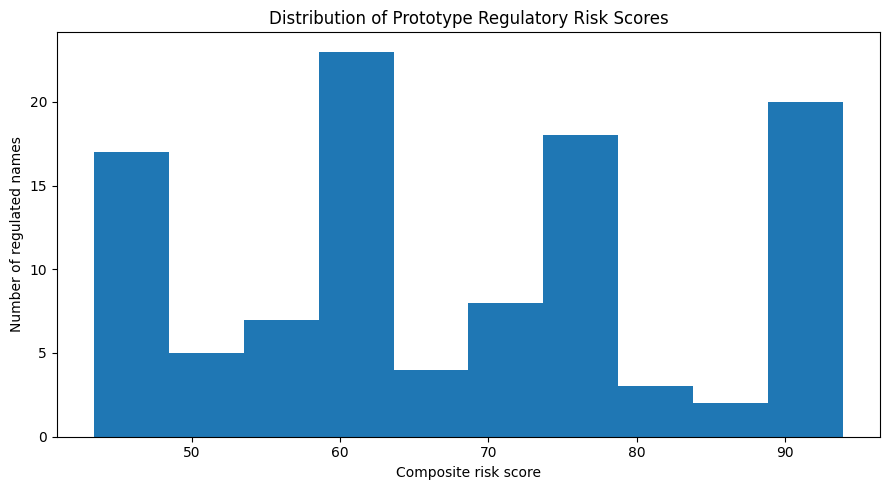

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(entity["Composite_Risk_Score"], bins=10)
plt.title("Distribution of Prototype Regulatory Risk Scores")
plt.xlabel("Composite risk score")
plt.ylabel("Number of regulated names")
plt.tight_layout()
plt.show()


## 9. Highest-scoring names in the prototype

In [9]:
top_entities = entity.sort_values("Composite_Risk_Score", ascending=False).head(10)

top_entities[
    [
        "Name",
        "Decision_Count",
        "Max_Severity",
        "Avg_Severity",
        "Latest_Decision_Date",
        "Composite_Risk_Score",
        "Prototype_Risk_Band"
    ]
]


,Name,Decision_Count,Max_Severity,Avg_Severity,Latest_Decision_Date,Composite_Risk_Score,Prototype_Risk_Band
86,Robert Bradshaw,2,5,5.0,2026-07-17,93.9,Very High
94,Simon Langford,2,5,5.0,2026-07-17,93.9,Very High
91,Sayers Solicitors LLP,2,5,5.0,2026-07-17,93.9,Very High
100,Syed Suhail Abbas Sibtain,2,5,5.0,2026-07-10,93.7,Very High
13,Azair Mahmood Alam,1,5,5.0,2026-08-25,89.9,Very High
87,Roundhay Solicitors,1,5,5.0,2026-08-25,89.9,Very High
66,Michael George Wooldridge,1,5,5.0,2026-08-19,89.8,Very High
65,Michael G Wooldridge,1,5,5.0,2026-08-19,89.8,Very High
101,Toby Richard Matthews,1,5,5.0,2026-08-13,89.6,Very High
80,RAW Clark LLP,1,5,5.0,2026-08-07,89.5,Very High


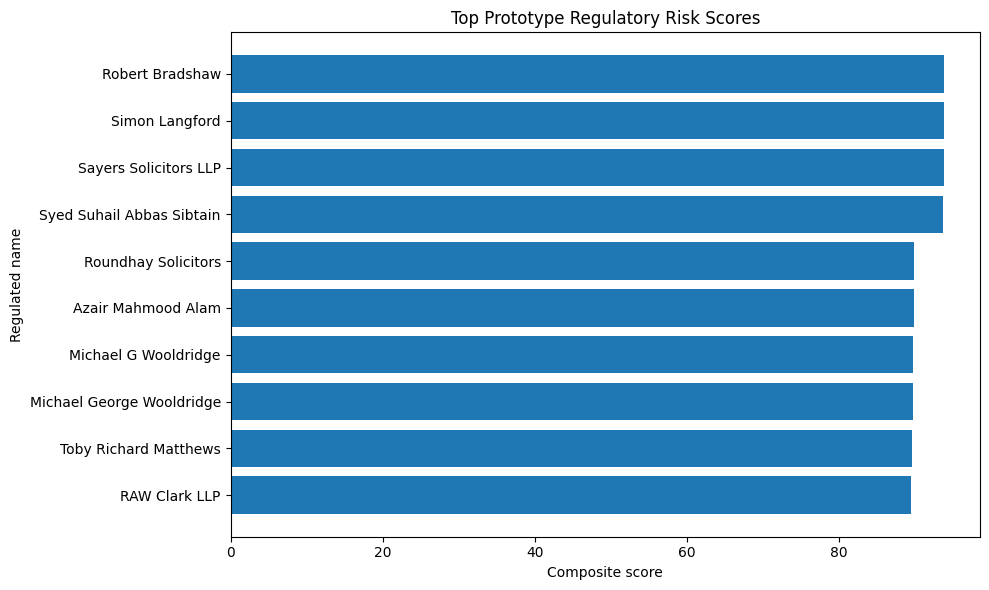

In [10]:
plot_top = top_entities.sort_values("Composite_Risk_Score")

plt.figure(figsize=(10, 6))
plt.barh(plot_top["Name"], plot_top["Composite_Risk_Score"])
plt.title("Top Prototype Regulatory Risk Scores")
plt.xlabel("Composite score")
plt.ylabel("Regulated name")
plt.tight_layout()
plt.show()


## 10. Explainability view

In [11]:
explainability_view = entity.sort_values("Composite_Risk_Score", ascending=False)[
    [
        "Name",
        "Decision_Count",
        "Max_Severity",
        "Avg_Severity",
        "Days_Since_Latest",
        "Repeat_Factor",
        "Recency_Score",
        "Composite_Risk_Score",
        "Prototype_Risk_Band"
    ]
]

explainability_view.head(15)


,Name,Decision_Count,Max_Severity,Avg_Severity,Days_Since_Latest,Repeat_Factor,Recency_Score,Composite_Risk_Score,Prototype_Risk_Band
86,Robert Bradshaw,2,5,5.0,41,0.666667,0.887671,93.9,Very High
94,Simon Langford,2,5,5.0,41,0.666667,0.887671,93.9,Very High
91,Sayers Solicitors LLP,2,5,5.0,41,0.666667,0.887671,93.9,Very High
100,Syed Suhail Abbas Sibtain,2,5,5.0,48,0.666667,0.868493,93.7,Very High
13,Azair Mahmood Alam,1,5,5.0,2,0.333333,0.994521,89.9,Very High
87,Roundhay Solicitors,1,5,5.0,2,0.333333,0.994521,89.9,Very High
66,Michael George Wooldridge,1,5,5.0,8,0.333333,0.978082,89.8,Very High
65,Michael G Wooldridge,1,5,5.0,8,0.333333,0.978082,89.8,Very High
101,Toby Richard Matthews,1,5,5.0,14,0.333333,0.961644,89.6,Very High
80,RAW Clark LLP,1,5,5.0,20,0.333333,0.945205,89.5,Very High


## 11. Sensitivity test

In [12]:
entity["Alternative_Score"] = (
    0.40 * entity["Max_Severity_Norm"] +
    0.20 * entity["Avg_Severity_Norm"] +
    0.30 * entity["Repeat_Factor"] +
    0.10 * entity["Recency_Score"]
) * 100

entity["Alternative_Score"] = entity["Alternative_Score"].round(1)

sensitivity = (
    entity[["Name", "Composite_Risk_Score", "Alternative_Score"]]
    .assign(
        Score_Difference=lambda x: (
            x["Alternative_Score"] - x["Composite_Risk_Score"]
        ).round(1)
    )
    .sort_values("Composite_Risk_Score", ascending=False)
)

sensitivity.head(15)


,Name,Composite_Risk_Score,Alternative_Score,Score_Difference
86,Robert Bradshaw,93.9,88.9,-5.0
94,Simon Langford,93.9,88.9,-5.0
91,Sayers Solicitors LLP,93.9,88.9,-5.0
100,Syed Suhail Abbas Sibtain,93.7,88.7,-5.0
13,Azair Mahmood Alam,89.9,79.9,-10.0
87,Roundhay Solicitors,89.9,79.9,-10.0
66,Michael George Wooldridge,89.8,79.8,-10.0
65,Michael G Wooldridge,89.8,79.8,-10.0
101,Toby Richard Matthews,89.6,79.6,-10.0
80,RAW Clark LLP,89.5,79.5,-10.0


### Why sensitivity matters

If rankings change materially when reasonable weights change, the model should not be treated as definitive. In legal and compliance settings, visible assumptions are preferable to false precision.


## 12. Export scored entity data

In [13]:
OUTPUT_PATH = Path("../data/processed/sra_entity_risk_scores.csv")
entity.sort_values("Composite_Risk_Score", ascending=False).to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Entities scored: {len(entity):,}")


Saved: ../data/processed/sra_entity_risk_scores.csv
Entities scored: 107


## Model summary

This notebook demonstrates an explainable legal-data risk framework that combines historical outcome severity, repeat decisions, and recency.

### Strengths
- transparent weights;
- explainable components;
- reproducible calculations;
- sensitivity analysis;
- clear distinction between historical regulatory data and present risk.

### Limitations
- the snapshots may not represent the full SRA decision population;
- severity weights are analytical assumptions, not validated coefficients;
- decision categories omit factual context;
- publication timing can affect recency;
- name matching may need stronger entity-resolution methods;
- historical outcomes do not establish current or future misconduct.

A future version could add decision-text NLP, richer entity resolution, external validation, and a Streamlit dashboard.
